# HW 5 Goncharov Evgenii

## EDA analysis

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('heart.csv')

df.head(8)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0


In [6]:
df['RestingECG'].unique()

array(['Normal', 'ST', 'LVH'], dtype=object)

## Feature Description

- **Age**: Age of the patient in years.
- **Sex**: Biological sex of the patient (`M` = male, `F` = female).
- **ChestPainType**: Type of chest pain reported by the patient. Common categories include `TA` (Typical Angina), `ATA` (Atypical Angina), `NAP` (Non-Anginal Pain), and `ASY` (Asymptomatic).
- **RestingBP**: Resting blood pressure measured in mm Hg.
- **Cholesterol**: Serum cholesterol level measured in mg/dl.
- **FastingBS**: Fasting blood sugar indicator, where `1` means fasting blood sugar is greater than 120 mg/dl, and `0` means it is 120 mg/dl or lower.
- **RestingECG**: Resting electrocardiogram results, such as `Normal`, `ST - T wave abnormality`, or `LVH - Left ventricular hypertrophy`.
- **MaxHR**: Maximum heart rate achieved by the patient during exercise.
- **ExerciseAngina**: Whether the patient experienced exercise-induced angina (`Y` = yes, `N` = no).
- **Oldpeak**: ST depression induced by exercise relative to rest. `0.0` is good, the more the worse.
- **ST_Slope**: Slope of the peak exercise ST segment (`Up`, `Flat`, `Down`). `Flat` or `Down` are signs of pathology.
- **HeartDisease**: Target variable indicating the presence of heart disease, where `1` means disease is present and `0` means it is absent.

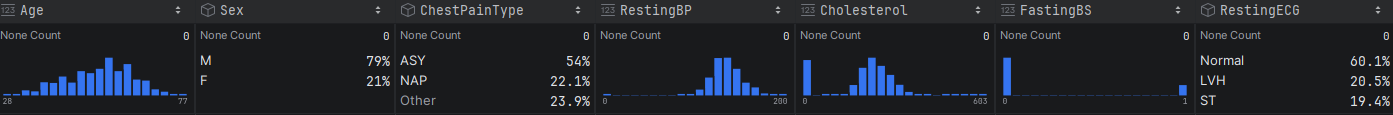

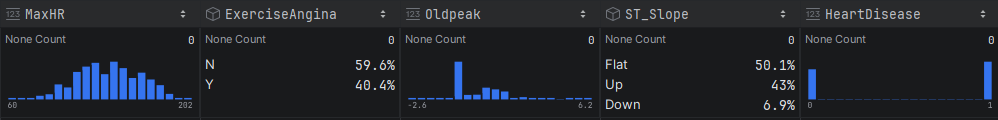

(images were automatically generated in PyCharm)

We can observe that there are zeros in `RestingBP` and `Cholesterol` columns, what is, actually, impossible, so it is looking like an outliers.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [3]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


## Filtering outliers

In [7]:
df['Cholesterol'] = df['Cholesterol'].replace(0, df['Cholesterol'].median())
df['RestingBP'] = df['RestingBP'].replace(0, df['RestingBP'].median())

## Observing dependencies

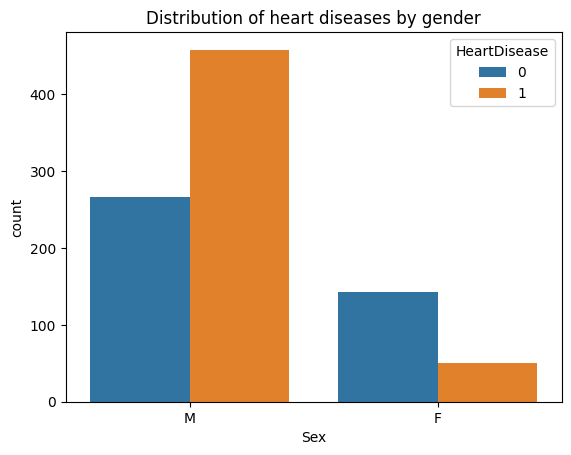

In [11]:
sns.countplot(data=df, x='Sex', hue='HeartDisease')
plt.title('Distribution of heart diseases by gender')
plt.show()

It is not appropriate to look and counts of `Sex`, because we have a class disbalance, let's look at probabilities

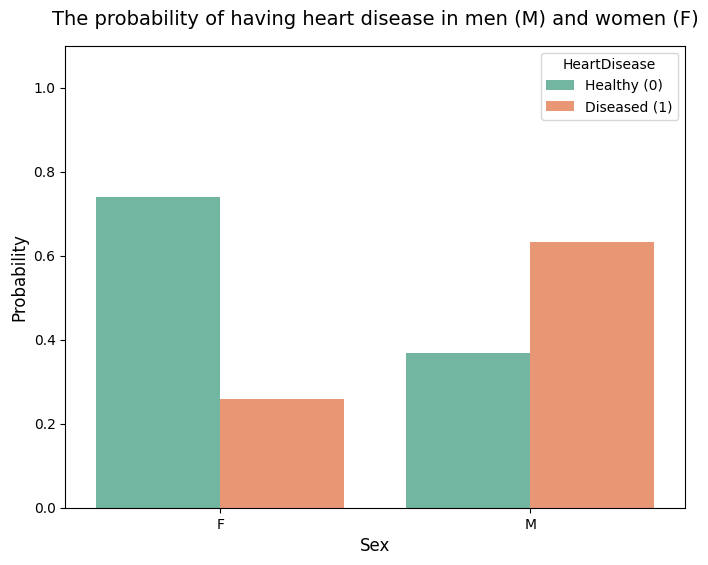

In [14]:
df_probs = (
    df.groupby('Sex')['HeartDisease']
    .value_counts(normalize=True)
    .rename('Probability')
    .reset_index()
)

plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=df_probs,
    x='Sex',
    y='Probability',
    hue='HeartDisease',
    palette='Set2'
)

plt.title('The probability of having heart disease in men (M) and women (F)', fontsize=14, pad=15)
plt.xlabel('Sex', fontsize=12)
plt.ylabel('Probability', fontsize=12)

handles, _ = ax.get_legend_handles_labels()
plt.legend(handles, ['Healthy (0)', 'Diseased (1)'], title='HeartDisease')

plt.ylim(0, 1.1)

plt.show()

So, we see that men have a heart disease more often

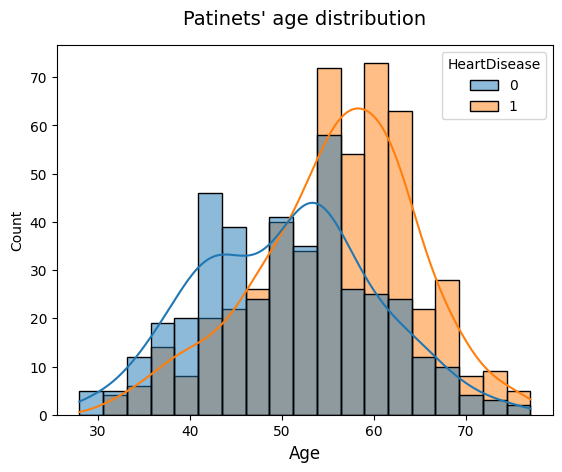

In [15]:
sns.histplot(data=df, x='Age', hue='HeartDisease', kde=True)
plt.title('Patinets\' age distribution', fontsize=14, pad=15)
plt.xlabel('Age', fontsize=12)
plt.show()

It is logical that older patients are more likely to experience the disease.

It is quite obvious that deviations from the norm of biological parameters will be more common in diseased patients. Let's take a better look at the codependency of the signs.

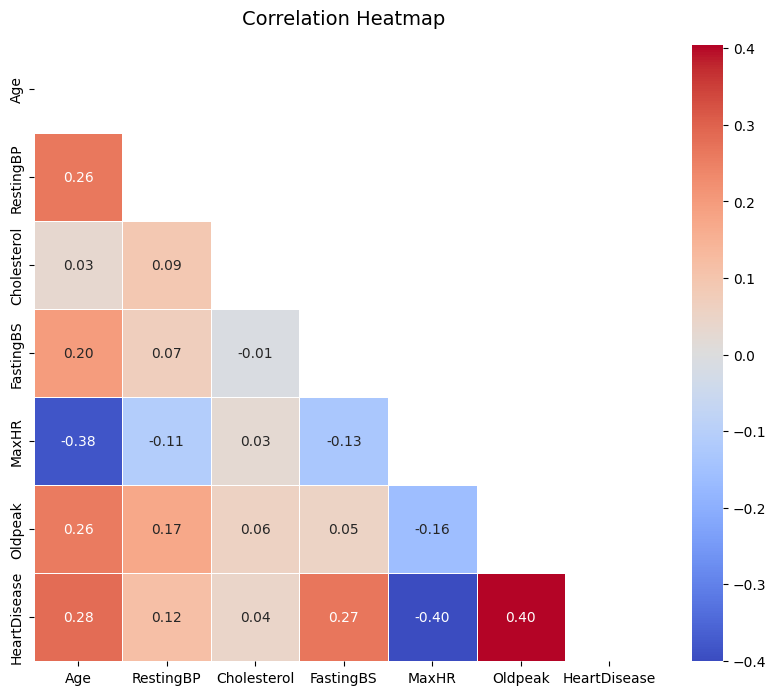

In [17]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", mask=mask, linewidths=.5)
plt.title('Correlation Matrix', fontsize=14, pad=15)
plt.title('Correlation Heatmap', fontsize=14, pad=15)
plt.show()

### 1. Feature to Target Correlation (`HeartDisease`)
* **Strongest Predictors**: `Oldpeak` (0.40) and `MaxHR` (-0.40) show the strongest linear relationship with the target variable. Higher ST depression (`Oldpeak`) and a lower maximum heart rate (`MaxHR`) are significantly associated with the presence of heart disease.
* **Moderate Predictors**: `Age` (0.28) and `FastingBS` (0.27) have a moderate positive correlation, indicating that older patients and those with elevated fasting blood sugar are at a higher risk of heart disease.
* **Weak Predictors**: `RestingBP` (0.12) and `Cholesterol` (0.04) demonstrate very weak linear correlations with the target. The near-zero correlation for cholesterol is likely an artifact caused by the anomalous zero values present in the dataset, which requires proper imputation.

### 2. Feature to Feature Correlation (Multicollinearity)
* **Age and Heart Rate**: The most notable relationship among independent features is the negative correlation between `Age` and `MaxHR` (-0.38). This is a biologically expected trend, as a person's maximum achievable heart rate naturally decreases as they get older.
* **Absence of Multicollinearity**: There are no highly correlated feature pairs (e.g., no correlation exceeds the 0.7 threshold). This is a highly positive finding for predictive modeling, as it means we do not have redundant numerical features and can safely include all of them in machine learning algorithms without multicollinearity issues.

## Trying 3D plot

In [24]:
import plotly.express as px
import plotly.graph_objects as go

In [26]:
df_3d = df.copy()
df_3d['Condition'] = df_3d['HeartDisease'].map({0: 'Healthy (0)', 1: 'Heart Disease (1)'})

fig = px.scatter_3d(
    data_frame=df_3d,
    x='Age',
    y='MaxHR',
    z='Oldpeak',
    color='Condition',
    color_discrete_map={'Healthy (0)': '#2ca02c', 'Heart Disease (1)': '#d62728'},
    opacity=0.7,
    title='3D Analysis: Age, Max Heart Rate, and ST Depression (Oldpeak)'
)

fig.update_traces(marker=dict(size=4))

x_min, x_max = df_3d['Age'].min(), df_3d['Age'].max()
y_min, y_max = df_3d['MaxHR'].min(), df_3d['MaxHR'].max()


x_grid, y_grid = np.meshgrid([x_min, x_max], [y_min, y_max])
z_grid = np.zeros_like(x_grid)


fig.add_trace(go.Surface(
    x=x_grid,
    y=y_grid,
    z=z_grid,
    opacity=0.2,
    colorscale=[[0, 'gray'], [1, 'gray']],
    showscale=False,
    name='Oldpeak = 0',
    hoverinfo='skip'
))

fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=40),
    legend_title_text='Patient Status'
)

fig.show()

### 3D Plot Insights:
This interactive 3D visualization combines the three most influential numerical features from our correlation matrix: `Age`, `MaxHR`, and `Oldpeak`.

By rotating the plot, we can observe a distinct visual separation (clustering) between healthy patients and those with heart disease. Specifically, the red cluster (`Heart Disease`) is likely to be more concentrated in the region characterized by older age, higher ST depression (`Oldpeak`), and lower maximum heart rate (`MaxHR`). Conversely, the green cluster (`Healthy`) occupies the opposite space, confirming our earlier findings that a healthy heart is typically associated with a younger age, the ability to reach a higher maximum heart rate, and minimal ST depression during exercise. But also we can see diseased people on the opposite side - too low ST depression (`Oldpeak`)

I also added a semi-transparent horizontal plane at `Oldpeak` = 0. Since an ST depression of 0 generally represents a normal baseline, this plane acts as a visual threshold.

# One-hot encoding

In our `heart.csv` dataset, the following nominal categorical features are perfect candidates for One-Hot Encoding:
* `Sex` (M, F)
* `ChestPainType` (ATA, NAP, ASY, TA)
* `RestingECG` (Normal, ST, LVH)
* `ExerciseAngina` (Y, N)
* `ST_Slope` (Up, Flat, Down)

## Final Conclusions

Based on this Exploratory Data Analysis, we can form a clear narrative about the factors associated with heart disease in this dataset:

1. **The High-Risk Profile**: The data indicates that patients most at risk for heart disease tend to be older, exhibit a significantly lower maximum heart rate (`MaxHR`) during physical activity, and show pronounced ST depression (`Oldpeak`) after exercise.
2. **Data Quality and Anomalies**: While there were no explicit `NaN` values, we uncovered hidden missing data encoded as zeros in the `Cholesterol` and `RestingBP` columns. These are biologically impossible values that must be imputed (e.g., using median values) to prevent machine learning models from learning false patterns.
3. **Modeling Readiness**: The dataset is highly viable for predictive modeling. We confirmed the absence of severe multicollinearity among numerical features, meaning all of them provide unique value. Once the hidden zero values are handled and categorical features (like `ChestPainType` and `ST_Slope`) are transformed using One-Hot Encoding, the data will be fully prepared for training robust classification algorithms.